# Exploratory Data Analysis - Brent, WTI, and the Relationship Between Them

This notebook presents a front-to-back analysis and interpretation of the cleaned data on the CL and BZ futures contracts from Databento, aiming to build intuition on how and why the contracts and their spreads move the way they do. We will start with basic raw plots of the data, explore some key insights, and leave with the primary implications for the strategy to be implemented. 

We will be looking at one-minute WTI (CL) and Brent (BZ) top-of-book data in the pilot week of Jun 1, 2026 to Jun 5, 2026. The primary object of interest is the synthetic spread

$$ S_t = CL_t - BZ_t $$

where both prices are represented using their top-of-book mid-prices:

$$ \text{mid}_t = \frac{\text{best bid}_t + \text{best ask}_t}{2} $$

The data are sampled on a regular one-minute grid. A row may contain either a new quote observed during that minute or a quote carried forward from a recent minute if a new quote for that minute was not available in the raw data. Before analyzing prices, we therefore first examine the time coverage, missing values, and frequency of fresh market activity.

In [150]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from settings import config

DATA_DIR = Path(config("DATA_DIR"))

ALIGNED_DATA = (
    DATA_DIR
    / "clean"
    / "brent_wti_aligned_1m_2026-06-01_2026-06-06.parquet"
)


In [151]:
# Load aligned data file
df = pd.read_parquet(ALIGNED_DATA)

# Ensure observations are ordered chronologically.
df = df.sort_index()

df.head()

,cl_bid_px_00,cl_ask_px_00,cl_bid_sz_00,cl_ask_sz_00,cl_mid,cl_instrument_id,cl_n_events,cl_n_trades,cl_volume,cl_is_roll_date,...,ls_mid,ls_instrument_id,ls_n_events,ls_n_trades,ls_volume,ls_is_roll_date,synth_mid,synth_bid,synth_ask,is_roll_date
ts_recv,,,,,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00+00:00,89.51,89.54,3.0,4.0,89.525,777566.0,416,40,46,False,...,-3.480,42016777.0,79,0,0,False,-3.485,-3.52,-3.45,False
2026-06-01 00:01:00+00:00,89.59,89.60,2.0,11.0,89.595,777566.0,271,18,25,False,...,-3.490,42016777.0,36,0,0,False,-3.480,-3.51,-3.45,False
2026-06-01 00:02:00+00:00,89.52,89.55,3.0,2.0,89.535,777566.0,248,18,19,False,...,-3.495,42016777.0,26,0,0,False,-3.500,-3.54,-3.46,False
2026-06-01 00:03:00+00:00,89.57,89.59,2.0,1.0,89.580,777566.0,186,18,33,False,...,-3.495,42016777.0,20,1,1,False,-3.495,-3.53,-3.46,False
2026-06-01 00:04:00+00:00,89.51,89.53,3.0,1.0,89.520,777566.0,594,43,60,False,...,-3.500,42016777.0,36,0,0,False,-3.510,-3.54,-3.48,False


The aligned dataset contains synchronized top-of-book observations for the two
outright futures contracts:

- `cl_mid`: WTI futures midprice
- `bz_mid`: Brent futures midprice
- `cl_bid_px_00`, `cl_ask_px_00`: best WTI bid and ask
- `bz_bid_px_00`, `bz_ask_px_00`: best Brent bid and ask
- `cl_n_events`, `bz_n_events`: number of market-data events observed during
  each one-minute bucket
- `cl_n_trades`, `bz_n_trades`: number of trades during each minute
- `cl_volume`, `bz_volume`: traded volume during each minute
- `synth_mid`: synthetic spread midprice, calculated as `CL mid - BZ mid`

The sample contains 7,021 consecutive one-minute observations extending from
00:00 UTC on June 1 through 21:00 UTC on June 5. The number of observed rows
exactly matches the number expected from a complete one-minute grid, and there
are no duplicate timestamps. This means the cleaned dataset is temporally regular: every minute in the sample
is represented exactly once. 

## 1. Raw Data Examination

#### Missing Values

In [152]:
core_columns = [
    "cl_mid",
    "bz_mid",
    "synth_mid",
]

missing_summary = pd.DataFrame(
    {
        "missing_count": df[core_columns].isna().sum(),
        "missing_percent": df[core_columns].isna().mean() * 100,
    }
)

missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False,
)

missing_summary

,missing_count,missing_percent
synth_mid,168,2.392822
bz_mid,154,2.193420
cl_mid,151,2.150691


The synthetic spread can only be calculated when both `CL` and `BZ` prices are
available simultaneously. Therefore, its missing count is expected to be at
least as large as the missing count of either leg individually.

These missing observations should be excluded from calculations that require
both contracts, rather than filled without limit. Unrestricted forward-filling
could create artificial periods in which the spread appears stable even though
one market is not actively updating.

### Freshness

In [153]:
df["cl_fresh"] = df["cl_n_events"] > 0
df["bz_fresh"] = df["bz_n_events"] > 0
df["both_fresh"] = df["cl_fresh"] & df["bz_fresh"]

In [154]:
freshness_summary = pd.DataFrame(
    {
        "fresh_minutes": [
            df["cl_fresh"].sum(),
            df["bz_fresh"].sum(),
            df["both_fresh"].sum(),
        ],
        "total_minutes": len(df),
        "fresh_percent": [
            df["cl_fresh"].mean() * 100,
            df["bz_fresh"].mean() * 100,
            df["both_fresh"].mean() * 100,
        ],
    },
    index=[
        "WTI fresh",
        "Brent fresh",
        "Both legs fresh",
    ],
)

freshness_summary.style.format(
    {
        "fresh_minutes": "{:,.0f}",
        "total_minutes": "{:,.0f}",
        "fresh_percent": "{:.2f}%",
    }
)

,fresh_minutes,total_minutes,fresh_percent
WTI fresh,"6,797","7,021",96.81%
Brent fresh,"6,771","7,021",96.44%
Both legs fresh,"6,759","7,021",96.27%



Both outright futures markets are highly active throughout most of the sample.
WTI receives at least one new event in approximately 96.8% of one-minute buckets,
while Brent receives one in approximately 96.4%. Both legs update during the
same minute approximately 96.3% of the time.

This indicates that most observations used to construct the synthetic spread
are based on recently active markets rather than long stretches of unchanged
quotes. The small share of non-fresh minutes is concentrated around particular
times of day, however, rather than being evenly distributed throughout the
sample.

## 2. Price Behavior of CL and BZ

We begin our analysis by examining the WTI (`CL`) and Brent (`BZ`) midprices individually
over the pilot week. Since the two contracts trade at different absolute price
levels, we then normalize both series to a common starting value to compare
their relative movements more directly.

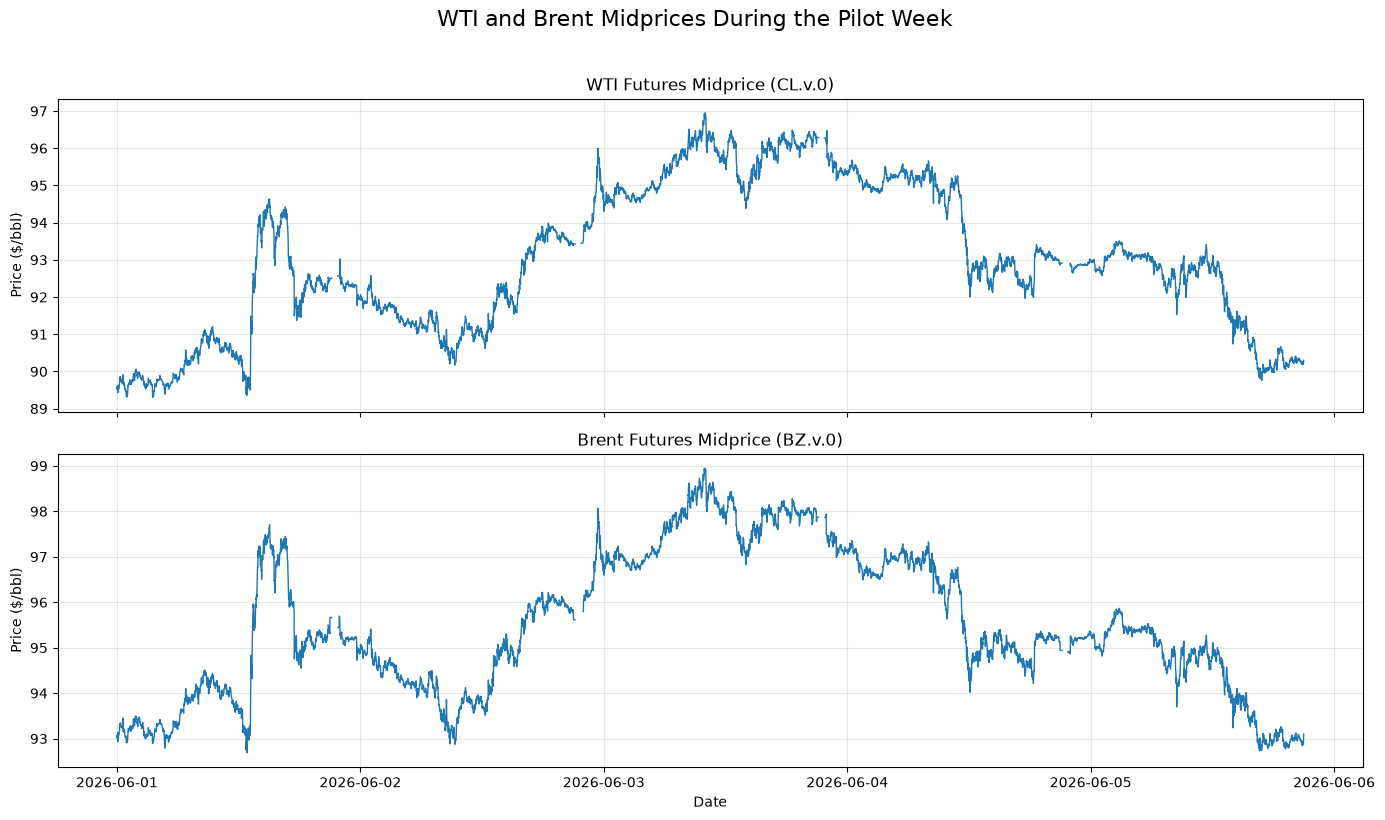

In [155]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 8),
    sharex=True,
)

axes[0].plot(
    df.index,
    df["cl_mid"],
    linewidth=1,
)

axes[0].set_title("WTI Futures Midprice (CL.v.0)")
axes[0].set_ylabel("Price ($/bbl)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    df.index,
    df["bz_mid"],
    linewidth=1,
)

axes[1].set_title("Brent Futures Midprice (BZ.v.0)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Price ($/bbl)")
axes[1].grid(alpha=0.3)

fig.suptitle(
    "WTI and Brent Midprices During the Pilot Week",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.show()

Both WTI and Brent display very similar broad movements over the pilot week.
This is intuitive because both contracts represent crude oil and are exposed to
many of the same global supply, demand, and macroeconomic forces. However, the
two price paths are not identical. Small differences in the size and timing of
their movements cause the Brent–WTI spread to widen and narrow over time.

The small difference between them—the Brent–WTI spread—mainly reflects:
- **Location**: WTI is priced at Cushing, Oklahoma; Brent reflects seaborne North Sea crude.
- **Transportation and export constraints**: WTI may trade cheaper when U.S. supply builds up or pipeline capacity is tight.
- **Regional supply and demand**: U.S.-specific conditions affect WTI, while Brent is more exposed to global and geopolitical conditions.

The visible similarity between the two contracts supports studying them as a
relative-value pair, although visual co-movement alone does not yet establish
that deviations between them will reliably reverse.

In [156]:
price_data = df[["cl_mid", "bz_mid"]].dropna().copy()

normalized_prices = (
    price_data
    .div(price_data.iloc[0])
    .mul(100)
)

normalized_prices = normalized_prices.rename(
    columns={
        "cl_mid": "WTI",
        "bz_mid": "Brent",
    }
)

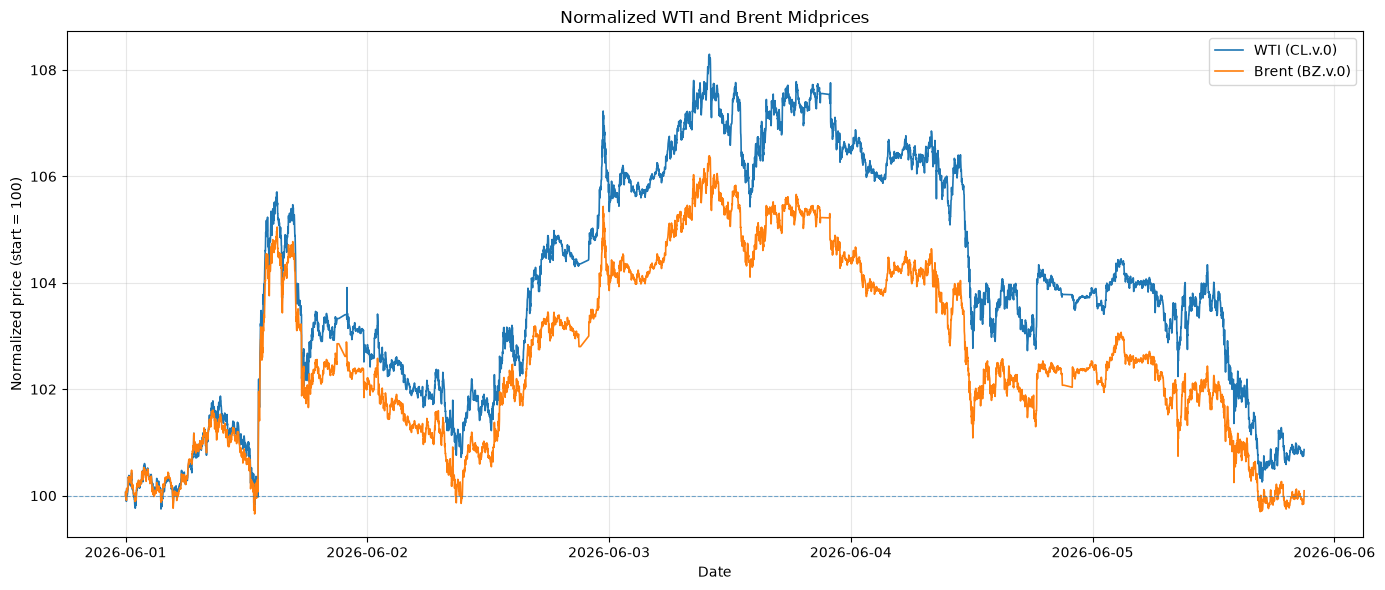

In [157]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    normalized_prices.index,
    normalized_prices["WTI"],
    label="WTI (CL.v.0)",
    linewidth=1.2,
)

ax.plot(
    normalized_prices.index,
    normalized_prices["Brent"],
    label="Brent (BZ.v.0)",
    linewidth=1.2,
)

ax.axhline(
    100,
    linewidth=0.8,
    linestyle="--",
    alpha=0.6,
)

ax.set_title("Normalized WTI and Brent Midprices")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price (start = 100)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

After normalizing both contracts to the same starting value, their close
co-movement becomes much easier to see. The two lines generally rise and fall
together, confirming that WTI and Brent share a strong common price component.

However, the lines do not remain perfectly overlapped. At several points, one
contract gains or loses more than the other before their relative performance
moves closer together again. **These temporary divergences are the source of
movement in the Brent–WTI spread and represent the behavior that a relative-value
strategy may attempt to exploit.**

## 3. Correlation Between WTI and Brent

WTI and Brent are exposed to many of the same global crude-oil market forces, so
we expect their short-term price movements to be positively correlated.

To measure this relationship, we calculate one-minute changes in each contract's
midprice:

$$ \Delta P_t = P_t - P_{t-1} $$

Using price changes rather than price levels helps isolate whether the two
contracts actually move together from one minute to the next.

In [158]:
price_changes = (
    df[["cl_mid", "bz_mid"]]
    .diff()
    .rename(
        columns={
            "cl_mid": "WTI",
            "bz_mid": "Brent",
        }
    )
    .dropna()
)

price_changes.head()

,WTI,Brent
ts_recv,,
2026-06-01 00:01:00+00:00,0.070,0.065
2026-06-01 00:02:00+00:00,-0.060,-0.040
2026-06-01 00:03:00+00:00,0.045,0.040
2026-06-01 00:04:00+00:00,-0.060,-0.045
2026-06-01 00:05:00+00:00,-0.090,-0.100


In [159]:
change_correlation = price_changes["WTI"].corr(
    price_changes["Brent"]
)

print(
    f"Correlation between one-minute WTI and Brent "
    f"price changes: {change_correlation:.3f}"
)

Correlation between one-minute WTI and Brent price changes: 0.929


The correlation between one-minute WTI and Brent price changes is **0.929**,
indicating that the contracts generally move in the same direction over short
intervals. At the same time, the
correlation is not perfect, meaning their movements sometimes differ in size or
direction. Those temporary differences generate changes in the Brent–WTI spread.

A high correlation alone does not establish mean reversion. It only confirms
that the two legs are sufficiently related for their relative movement to be a
meaningful object of analysis.

## 4. Behavior of the Brent-WTI Spread

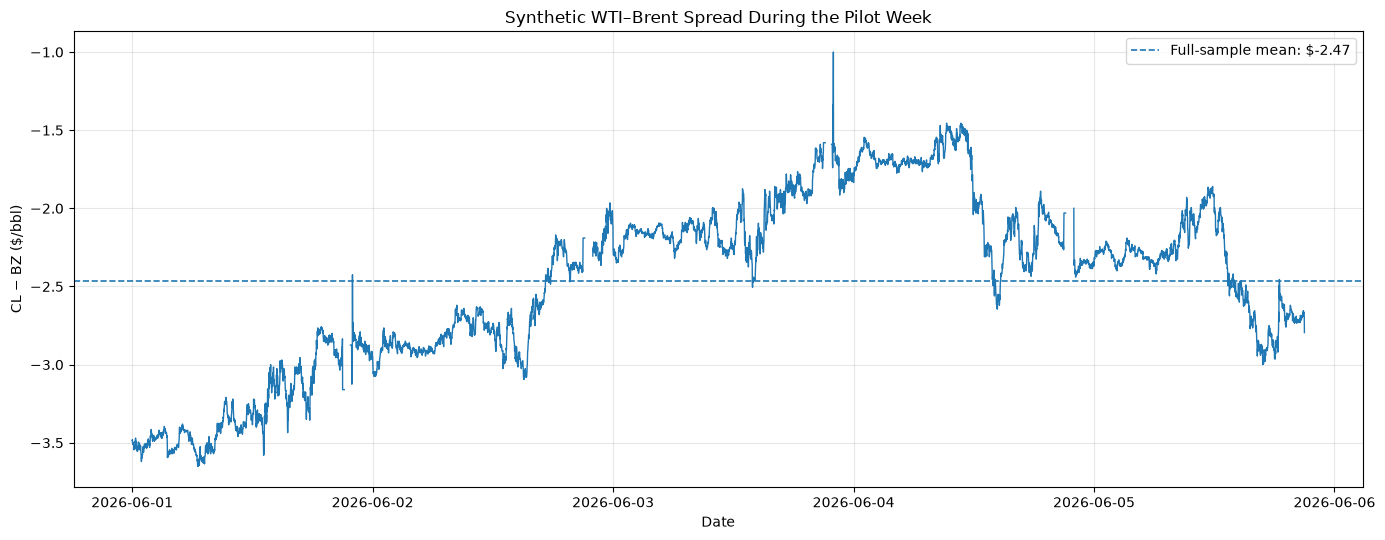

In [160]:
spread = df["cl_mid"] - df["bz_mid"]

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(
    spread.index,
    spread,
    linewidth=1,
)

ax.axhline(
    spread.mean(),
    linestyle="--",
    linewidth=1.2,
    label=f"Full-sample mean: ${spread.mean():.2f}",
)

ax.set_title("Synthetic WTI–Brent Spread During the Pilot Week")
ax.set_xlabel("Date")
ax.set_ylabel("CL − BZ ($/bbl)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Although the spread repeatedly moves above and below its full-sample mean, it
does not appear to fluctuate tightly around one constant level. Instead, its
local center appears to change over time. For example, the spread remains above
the weekly mean for an extended period in the middle of the sample rather than
immediately returning to it.

This suggests that a strategy based on one fixed weekly mean would likely react
too slowly to changes in the relationship between WTI and Brent.

In [161]:
daily_spread_summary = (
    spread.groupby(spread.index.date)
    .agg(
        mean="mean",
        std="std",
        minimum="min",
        maximum="max",
    )
)

daily_spread_summary.index.name = "Date"
daily_spread_summary.head()

,mean,std,minimum,maximum
Date,,,,
2026-06-01,-3.261303,0.252608,-3.650,-2.425
2026-06-02,-2.684465,0.265656,-3.095,-1.965
2026-06-03,-2.059109,0.197072,-2.505,-1.000
2026-06-04,-1.930122,0.315150,-2.645,-1.455
2026-06-05,-2.388866,0.272588,-3.000,-1.860


The daily statistics reinforce what is visible in the weekly chart: both the
average spread level and its range vary from day to day. The spread is therefore
not simply oscillating around one stable value throughout the full sample.

This distinction is important for the strategy. We are not necessarily looking
for reversion toward one permanent Brent–WTI spread. Instead, the potential
opportunity appears to involve shorter-term movements around a local,
time-varying relationship.

## 5. Deviations from a Local Mean

Because the spread does not remain centered around one constant weekly average,
we compare it with rolling means calculated over several horizons.

For a rolling window \(w\), define the deviation as

$$ D_t^{(w)} = S_t - \bar{S}_t^{(w)} $$


where $S_t$ is the current synthetic spread and $\bar{S}_t^{(w)}$ is its
trailing average over the previous $w$ minutes.

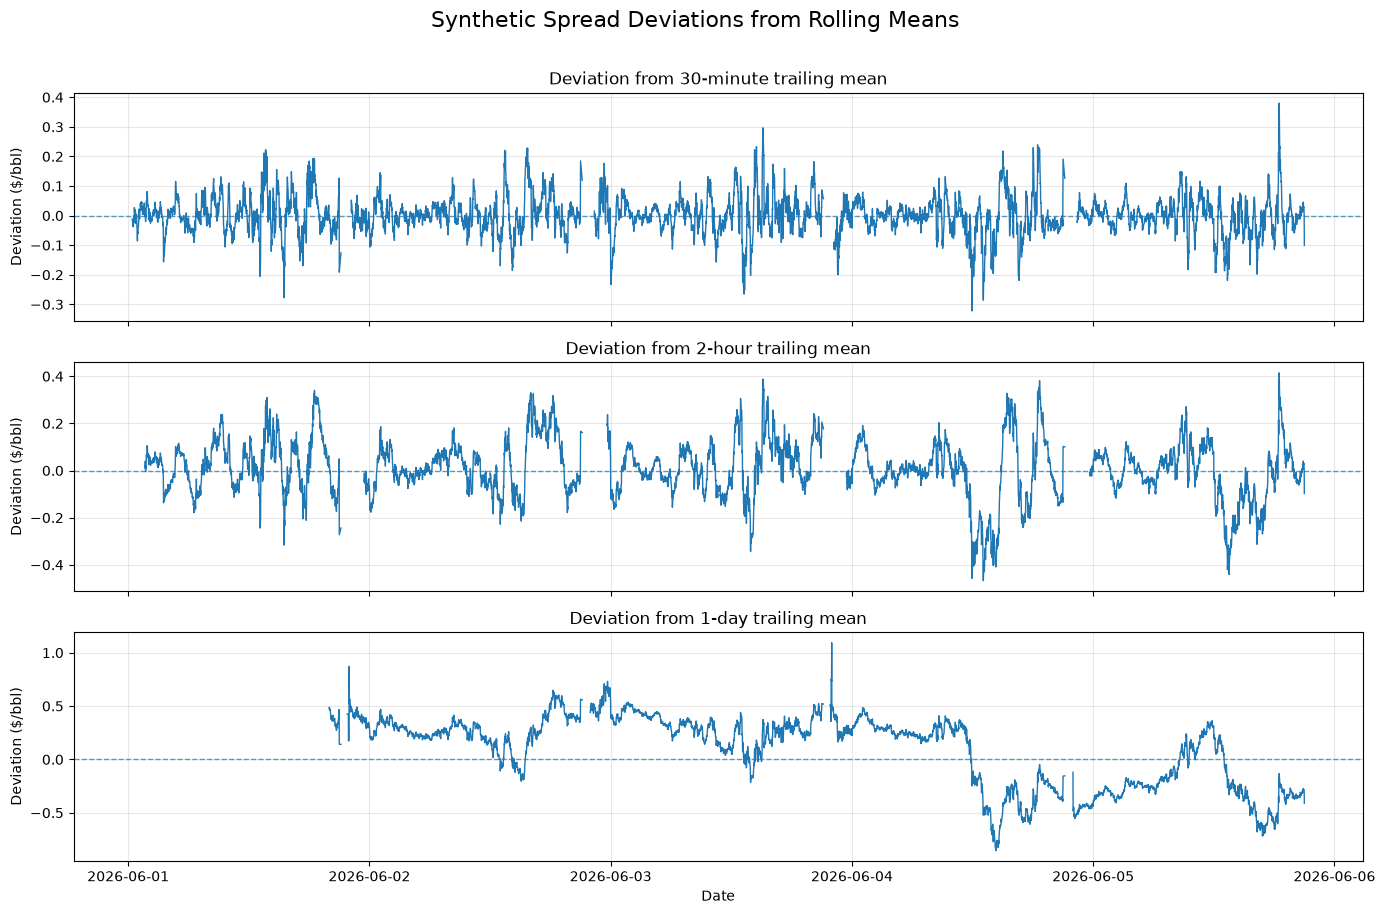

In [180]:
windows = {
    "30-minute": ("30min", 25),
    "2-hour": ("2h", 100),
    "1-day": ("1D", 1200),
}

spread_df = df[["synth_mid"]].copy()

for label, (window, min_periods) in windows.items():
    rolling_mean = (
        spread_df["synth_mid"]
        .rolling(
            window=window,
            min_periods=min_periods,
            center = False
        )
        .mean()
    )

    spread_df[f"{label}_deviation"] = (
        spread_df["synth_mid"] - rolling_mean
    )

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 9),
    sharex=True,
)

for ax, label in zip(axes, windows):
    column = f"{label}_deviation"

    ax.plot(
        spread_df.index,
        spread_df[column],
        linewidth=1,
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
    )

    ax.set_title(f"Deviation from {label} trailing mean")
    ax.set_ylabel("Deviation ($/bbl)")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")

fig.suptitle(
    "Synthetic Spread Deviations from Rolling Means",
    fontsize=16,
    y=1.01,
)

plt.tight_layout()
plt.show()

*Values are missing in the first day of the 1-day trailing mean plot due to the fact that by that point, there is not enough data to compute a 1-day trailing mean. This applies to a lesser extent to the beginning of the 2-hour trailing mean as well.*

As expected, deviations are much more closely centered around their shorter rolling averages and frequently change direction and cross them. 

The 30-minute deviation is relatively small and adjusts quickly because its
reference mean responds rapidly to new price movements. This makes it sensitive
to very short-term fluctuations, but it may also cause the estimated equilibrium
to move too quickly.

The 1-day deviation behaves differently. It remains positive or negative for
extended periods because the daily average adjusts slowly when the spread's level
changes. This suggests that a one-day reference may be too stale for an intraday
strategy.

The 2-hour window appears to provide a reasonable middle ground in this sample:
it is slow enough to identify meaningful deviations, but responsive enough to
adapt to changes in the spread's local level.

## 6. Distribution of Two-Hour Deviations

The previous section showed that the spread repeatedly moves above and below its
2-hour rolling mean. To continue our analysis, we will examine the distribution of those deviations:

$$ D_t = S_t - \bar{S}_t^{(2h)} $$

A distribution centered near zero would indicate that the spread spends similar
amounts of time above and below its recent local average. The width of the
distribution shows the typical size of these deviations.

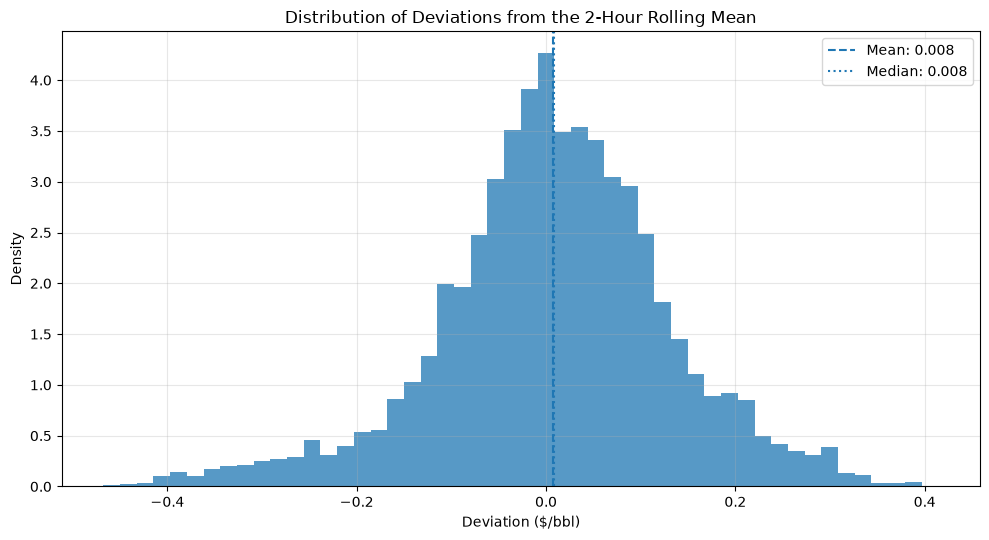

In [163]:
two_hour_rolling_mean = df["synth_mid"].rolling(
        window = 120,
        min_periods = 120,
    ).mean()

two_hour_deviation = (
    df["synth_mid"] - two_hour_rolling_mean
)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.hist(
    two_hour_deviation,
    bins=50,
    density=True,
    alpha=0.75,
)

ax.axvline(
    two_hour_deviation.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {two_hour_deviation.mean():.3f}",
)

ax.axvline(
    two_hour_deviation.median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median: {two_hour_deviation.median():.3f}",
)

ax.set_title("Distribution of Deviations from the 2-Hour Rolling Mean")
ax.set_xlabel("Deviation ($/bbl)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [164]:
deviation_stats = pd.Series(
    {
        "Mean": two_hour_deviation.mean(),
        "Median": two_hour_deviation.median(),
        "Standard deviation": two_hour_deviation.std(),
        "2.5th percentile": two_hour_deviation.quantile(0.025),
        "25th percentile": two_hour_deviation.quantile(0.25),
        "75th percentile": two_hour_deviation.quantile(0.75),
        "97.5th percentile": two_hour_deviation.quantile(0.975),
    },
    name="2-hour deviation ($/bbl)",
).to_frame()

deviation_stats.style.format("{:.3f}")

,2-hour deviation ($/bbl)
Mean,0.008
Median,0.008
Standard deviation,0.123
2.5th percentile,-0.281
25th percentile,-0.058
75th percentile,0.083
97.5th percentile,0.256


The distribution is centered very close to zero, with the mean and median both
near zero. This indicates that the spread spends roughly balanced amounts of
time above and below its 2-hour rolling average.

Most observations are concentrated near zero, while larger positive and negative
deviations occur less frequently. In this sample, the middle 50% of deviations
falls between approximately **-0.058** and **0.083**
dollars per barrel, while roughly 95% fall between **-0.281** and
**0.256**.

The shape is broadly bell-like, although it is not perfectly normal. This means
that large deviations are unusual relative to the typical behavior of the
spread, which may make them useful candidates for future entry signals.

In [165]:
reversion_data = spread_df[
    ["synth_mid", "2-hour_deviation"]
].dropna().copy()

deviation_labels = [
    "Large negative",
    "Moderate negative",
    "Near zero",
    "Moderate positive",
    "Large positive",
]

reversion_data["deviation_group"] = pd.qcut(
    reversion_data["2-hour_deviation"],
    q=5,
    labels=deviation_labels,
)

future_horizons = {
    "5 minutes": 5,
    "15 minutes": 15,
    "30 minutes": 30,
    "60 minutes": 60,
}

for label, minutes in future_horizons.items():
    reversion_data[label] = (
        reversion_data["synth_mid"].shift(-minutes)
        - reversion_data["synth_mid"]
    )

In [166]:
future_change_summary = (
    reversion_data
    .groupby("deviation_group", observed=True)[list(future_horizons)]
    .mean()
)

future_change_summary.style.format("{:.3f}")

,5 minutes,15 minutes,30 minutes,60 minutes
deviation_group,,,,
Large negative,0.003,0.009,0.015,0.042
Moderate negative,0.003,0.008,0.024,0.039
Near zero,0.001,0.009,0.015,0.021
Moderate positive,0.000,0.000,-0.009,-0.022
Large positive,-0.006,-0.017,-0.026,-0.043


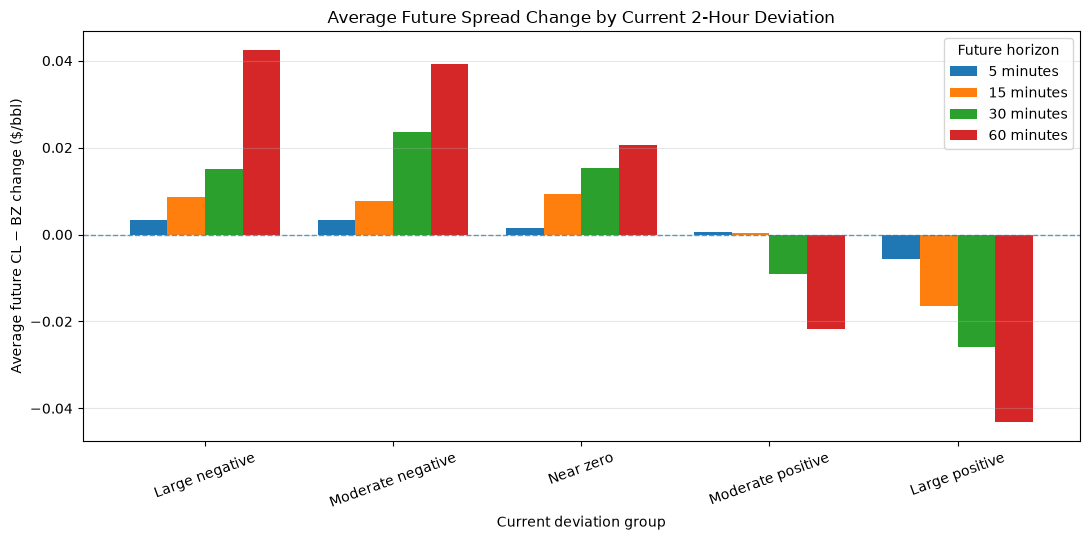

In [167]:
ax = future_change_summary.plot(
    kind="bar",
    figsize=(11, 5.5),
    width=0.8,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_title(
    "Average Future Spread Change by Current 2-Hour Deviation"
)
ax.set_xlabel("Current deviation group")
ax.set_ylabel("Average future CL − BZ change ($/bbl)")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Future horizon")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The future spread changes generally move in the opposite direction from the
current deviation. Observations in the large-negative group tend to be followed
by increases in the spread, while observations in the large-positive group tend
to be followed by decreases. However, there seems to be a tendency to change in the negative direction rather than positive following near zero changes and even in the moments imediately following moderate positive changes, indicating that this tendency is best used for large negative and large positive changes, whose following changes are much more consistently predicatable

This pattern provides more direct evidence of mean-reverting behavior than the
earlier histogram, especially for large deviations. The histogram showed that extreme deviations are uncommon;
this analysis tests whether those deviations are subsequently corrected.

## 8. Intraday Patterns and Session Boundaries

Market behavior may differ substantially across the trading day. In particular,
liquidity and price continuity can deteriorate near the daily exchange break.

To identify these patterns, we examine the typical magnitude of one-minute spread
changes and the rolling correlation between WTI and Brent for each UTC hour.

In [168]:
intraday_data = df[
    ["cl_mid", "bz_mid", "synth_mid"]
].copy()

# One-minute movement in the synthetic spread
intraday_data["spread_change"] = (
    intraday_data["synth_mid"].diff()
)

# One-minute changes in the two legs
intraday_data["cl_change"] = (
    intraday_data["cl_mid"].diff()
)

intraday_data["bz_change"] = (
    intraday_data["bz_mid"].diff()
)

# Two-hour rolling correlation of one-minute leg changes
intraday_data["rolling_correlation"] = (
    intraday_data["cl_change"]
    .rolling(window=120, min_periods=60)
    .corr(intraday_data["bz_change"])
)

intraday_data["hour_utc"] = intraday_data.index.hour

In [169]:
intraday_summary = (
    intraday_data
    .groupby("hour_utc")
    .agg(
        median_absolute_spread_change=(
            "spread_change",
            lambda x: x.abs().median(),
        ),
        median_rolling_correlation=(
            "rolling_correlation",
            "median",
        ),
    )
)

intraday_summary.head()

,median_absolute_spread_change,median_rolling_correlation
hour_utc,,
0,0.010,0.883249
1,0.010,0.949234
2,0.005,0.955529
3,0.005,0.950047
4,0.005,0.945589


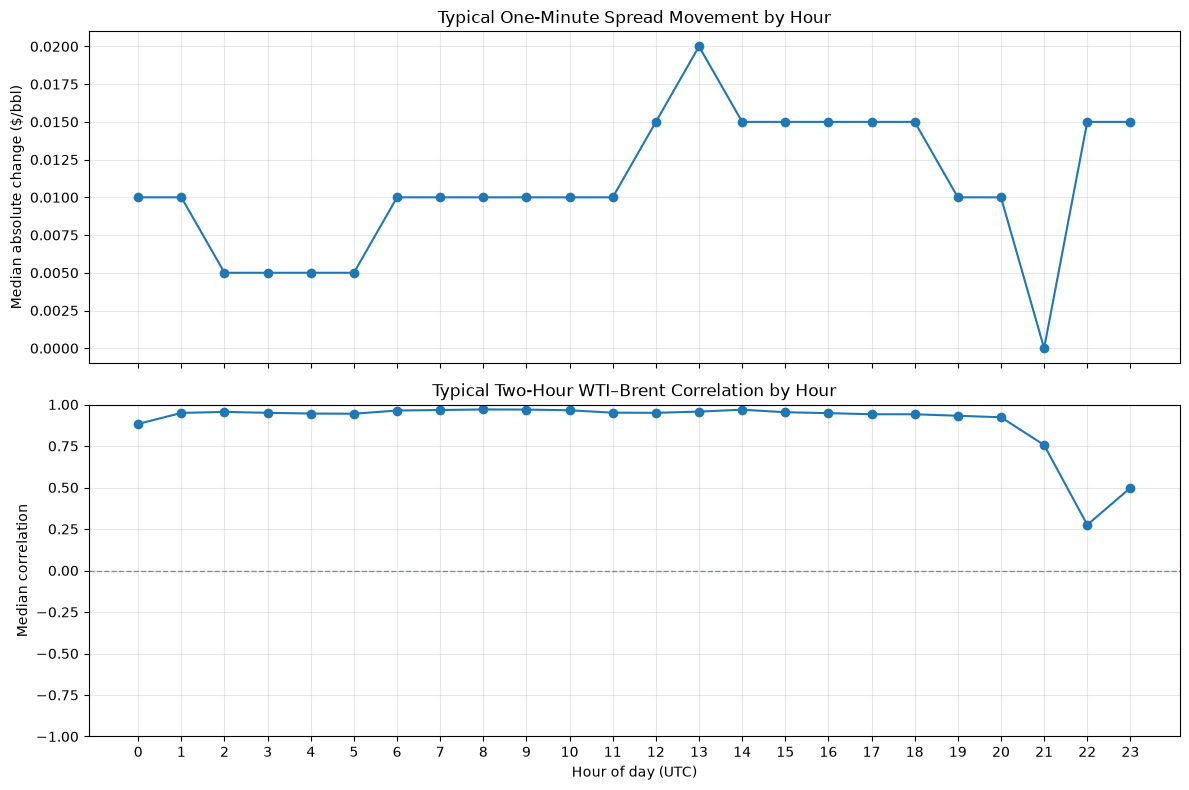

In [170]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
)

axes[0].plot(
    intraday_summary.index,
    intraday_summary["median_absolute_spread_change"],
    marker="o",
)

axes[0].set_title(
    "Typical One-Minute Spread Movement by Hour"
)
axes[0].set_ylabel("Median absolute change ($/bbl)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    intraday_summary.index,
    intraday_summary["median_rolling_correlation"],
    marker="o",
)

axes[1].axhline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

axes[1].set_title(
    "Typical Two-Hour WTI–Brent Correlation by Hour"
)
axes[1].set_xlabel("Hour of day (UTC)")
axes[1].set_ylabel("Median correlation")
axes[1].set_xticks(range(24))
axes[1].set_ylim(-1, 1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Throughout the day, we see through the correlation plot that price changes in Brent and WTI move largely close together until the last couple of hours. Thus, changes in spread during those hours should not necessarily be interpreted in the same way as others, as these can be more in response to market structure and trading behavior rather than ordinary intraday deviations. When one or both
markets are inactive, stale quotes and the reopening process can create apparent
jumps that do not represent a normal, immediately tradeable mean-reversion
opportunity.

The strategy should therefore avoid forming or carrying positions through this
period, and calculations involving rolling means, correlations, or future
returns should not treat the break as a normal sequence of consecutive
one-minute observations.

## 9. Rolling Stationarity of the Synthetic Spread

The mean-reversion strategy assumes that the Brent–WTI spread has recently been
fluctuating around a relatively stable local level. If the spread is instead
following a persistent trend or random walk, a large deviation may represent a
permanent change rather than a temporary dislocation.

We therefore apply stationarity tests to rolling two-hour windows of the raw
synthetic spread. This mirrors the intended strategy implementation: a signal
would only be acted upon when the spread has displayed sufficiently stationary
behavior over its recent lookback window.

Two complementary tests are used:

- The Augmented Dickey–Fuller test, whose null hypothesis is nonstationarity.
- The KPSS test, whose null hypothesis is stationarity.

A window is classified as passing only when the ADF test rejects
nonstationarity and the KPSS test does not reject stationarity.

In [195]:
from statsmodels.tsa.stattools import adfuller, kpss

def rolling_stationarity_tests(
    spread,
    window_size,
    step_size=30,
    minimum_observations=None,
    active_start_hour=0,
    active_end_hour=20,
    significance_level=0.05,
):
    if minimum_observations is None:
        minimum_observations = int(window_size * 0.8)

    results = []

    for end_position in range(
        window_size,
        len(spread) + 1,
        step_size,
    ):
        window = spread.iloc[
            end_position - window_size:end_position
        ]

        end_timestamp = window.index[-1]

        if not (
            active_start_hour
            <= end_timestamp.hour
            <= active_end_hour
        ):
            continue

        window = window.dropna()

        if len(window) < minimum_observations:
            continue

        adf_pvalue = adfuller(
            window,
            regression="c",
            autolag="AIC",
        )[1]

        try:
            kpss_pvalue = kpss(
                window,
                regression="c",
                nlags="auto",
            )[1]
        except ValueError:
            continue

        results.append(
            {
                "timestamp": end_timestamp,
                "adf_pvalue": adf_pvalue,
                "kpss_pvalue": kpss_pvalue,
                "adf_pass": adf_pvalue < significance_level,
                "kpss_pass": kpss_pvalue > significance_level,
            }
        )

    results = pd.DataFrame(results).set_index("timestamp")

    results["both_pass"] = (
        results["adf_pass"]
        & results["kpss_pass"]
    )

    return results

spread = df["synth_mid"]

stationarity_1h = rolling_stationarity_tests(
    spread,
    window_size=60,
)

stationarity_2h = rolling_stationarity_tests(
    spread,
    window_size=120,
)

/var/folders/jg/hg4078dn71d7q2w1mzkvkjm00000gn/T/ipykernel_70802/3381084666.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_pvalue = kpss(
/var/folders/jg/hg4078dn71d7q2w1mzkvkjm00000gn/T/ipykernel_70802/3381084666.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_pvalue = kpss(
/var/folders/jg/hg4078dn71d7q2w1mzkvkjm00000gn/T/ipykernel_70802/3381084666.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_pvalue = kpss(
/var/folders/jg/hg4078dn71d7q2w1mzkvkjm00000gn/T/ipykernel_70802/3381084666.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up

In [196]:
window_comparison = pd.DataFrame(
    {
        "1-hour": {
            "Windows tested": len(stationarity_1h),
            "ADF pass rate": stationarity_1h["adf_pass"].mean(),
            "KPSS pass rate": stationarity_1h["kpss_pass"].mean(),
            "Both pass": stationarity_1h["both_pass"].mean(),
        },
        "2-hour": {
            "Windows tested": len(stationarity_2h),
            "ADF pass rate": stationarity_2h["adf_pass"].mean(),
            "KPSS pass rate": stationarity_2h["kpss_pass"].mean(),
            "Both pass": stationarity_2h["both_pass"].mean(),
        },
    }
).T

window_comparison.style.format(
    {
        "Windows tested": "{:.0f}",
        "ADF pass rate": "{:.1%}",
        "KPSS pass rate": "{:.1%}",
        "Both pass": "{:.1%}",
    }
)

,Windows tested,ADF pass rate,KPSS pass rate,Both pass
1-hour,209,12.4%,32.1%,8.1%
2-hour,207,12.6%,19.3%,6.3%


The stationarity tests provide a more cautious view of the spread than the
earlier rolling-mean plots.

The Augmented Dickey–Fuller test rejects nonstationarity in only about 12%–13%
of the tested windows. The KPSS test is somewhat more favorable, especially for
the 1-hour window, but both tests simultaneously support stationarity in only
8.1% of 1-hour windows and 6.3% of 2-hour windows.

Shortening the lookback from two hours to one hour improves the KPSS pass rate,
but does not materially change the ADF result. This suggests that the spread may
sometimes remain locally centered over shorter periods, while still displaying
enough persistence or trending behavior that strong statistical evidence of
mean reversion is relatively uncommon.

The result does not invalidate the strategy, but it does show that stationarity
cannot be assumed. Mean-reverting conditions appear to occur in specific
regimes rather than throughout the entire trading day. Thus, stationarity should be treated as a selective regime filter rather than as a
permanent property of the Brent–WTI spread.

The strategy should not enter a position merely because the spread has reached
an extreme deviation or z-score. A signal should only be considered when the
recent spread history also shows evidence of a stable local relationship.

Because requiring both ADF and KPSS to pass would admit relatively few trades,
the final strategy should compare several possible filters during backtesting:

- a strict rule requiring both tests to support stationarity;
- a looser rule using one test together with additional evidence such as a
  negative mean-reversion coefficient or short estimated half-life;
- or stationarity measures used as continuous signal-quality features rather
  than a binary pass/fail gate.

The one-hour window provides slightly more qualifying regimes, but the higher
pass rate alone does not establish that it is superior. The final lookback
should be selected according to out-of-sample trading performance, signal
frequency, and realized reversion after transaction costs.

Regardless of the exact rule, stationarity testing should be performed only
within active trading sessions and should be reset after maintenance breaks and
contract rolls.

## 9. Executing with the Listed Spread

The strategy signal has so far been defined using the synthetic spread

$$
S_t^{(synthetic)} = CL_t - BZ_t
$$

constructed from the two outright futures contracts.

One possible implementation is to trade the two legs separately. An alternative
is to generate the signal from the synthetic spread but execute the position
through an exchange-listed Brent–WTI spread contract.

This would be attractive because the listed spread trades through a single order
book, reducing legging risk and potentially lowering transaction costs. However,
this approach is only valid if the listed contract closely tracks the same
relative-price exposure represented by the synthetic signal.

We therefore compare the synthetic spread with the listed contract whose
maturities most closely match the active continuous WTI and Brent contracts.

It is worth clarifying which specific CL and BZ contracts in the listed spread correspond to those which we have been using in our analysis of the synthetic spread. Our synthetic spread was constructed using CL.v.0 and BZ.v.0, which represent a *continuous representation* in Databento of the CL and BZ contracts for data purposes. This allows for straightforward examination of the futures prices over time, as individual contracts will expire regularly. The CL.v.0/BZ.v.0 format is interpreted by Databento as follows:
- **CL/BZ**: The product being traded
- **v**: Rank contracts according to *previous day trading volume*
- **0**: Choose the contract ranked the highest

Thus, when pulling data, Databento will, for all time steps, find the specific contract that meets these criteria and assign that to CL.v.0/BZ.v.0. For all of the pilot dates in the data we have been using thus far, the specific contracts that were assigned are **CLN6** (*N* = expires in July, *6* = 2026) and **BZQ6** (*Q* = expires in August, *6* = 2026). The difference in month is due to the fact that CL and BZ have different expiration schedules: CLN6 remained active in early June and didn't terminate until later that month, while BZN6 had already stopped trading at the end of May because BZ trading terminates on the last UK business day of the second month preceding its named contract month. Thus, the corresponding listed spread to our synthetic spread would be 

$$
S_t^{(listed)} = CLN6_t - BZQ6_t
$$

For the purposes of this section, we will compare this spread's pricing data with our synthetic spread's pricing data to determine whether executing our strategy with the listed spread that corresponds to the synthetic spread from which the trading signal is generated would be a feasible option. 

In [171]:
LISTED_SPREAD_FILE = (
    DATA_DIR
    / "clean"
    / "cln6-bzq6_1m_2026-06-01_2026-06-06.parquet"
)

listed = pd.read_parquet(LISTED_SPREAD_FILE).sort_index()

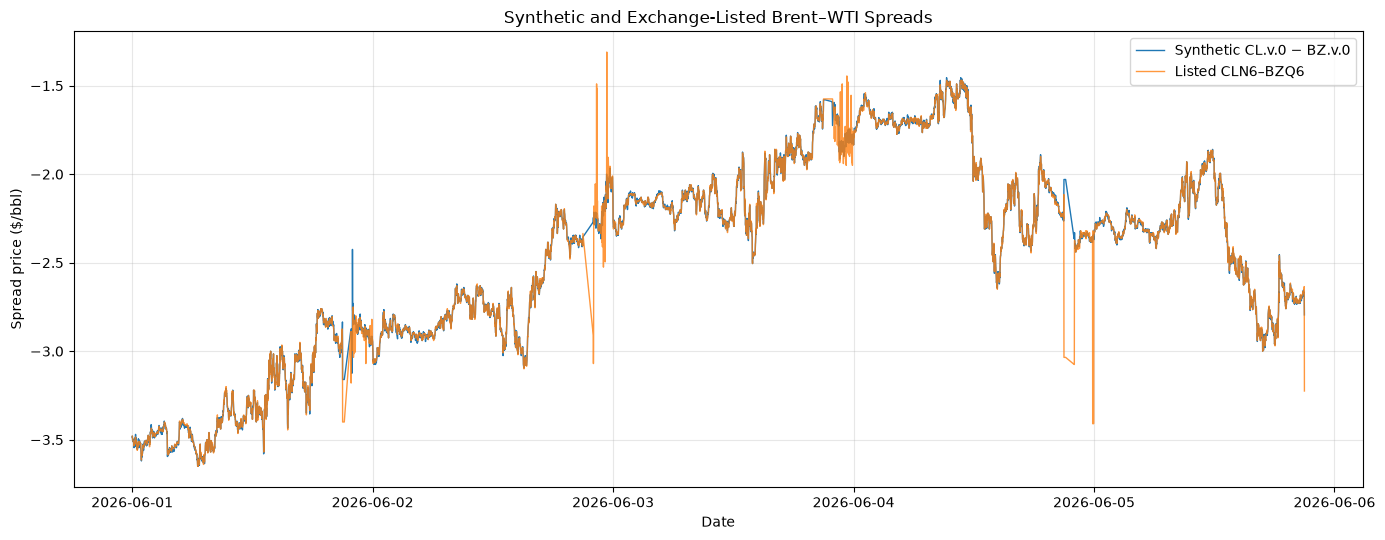

In [172]:
listed = listed[listed["mid"].between(-10, 5)]
listed_mid = listed["mid"].rename("listed_mid")
spread_comparison = pd.concat(
    [
        df["synth_mid"].rename("synthetic_mid"),
        listed_mid,
    ],
    axis=1,
    join="inner",
).dropna()

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(
    spread_comparison.index,
    spread_comparison["synthetic_mid"],
    label="Synthetic CL.v.0 − BZ.v.0",
    linewidth=1,
)

ax.plot(
    spread_comparison.index,
    spread_comparison["listed_mid"],
    label="Listed CLN6–BZQ6",
    linewidth=1,
    alpha=0.8,
)

ax.set_title("Synthetic and Exchange-Listed Brent–WTI Spreads")
ax.set_xlabel("Date")
ax.set_ylabel("Spread price ($/bbl)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

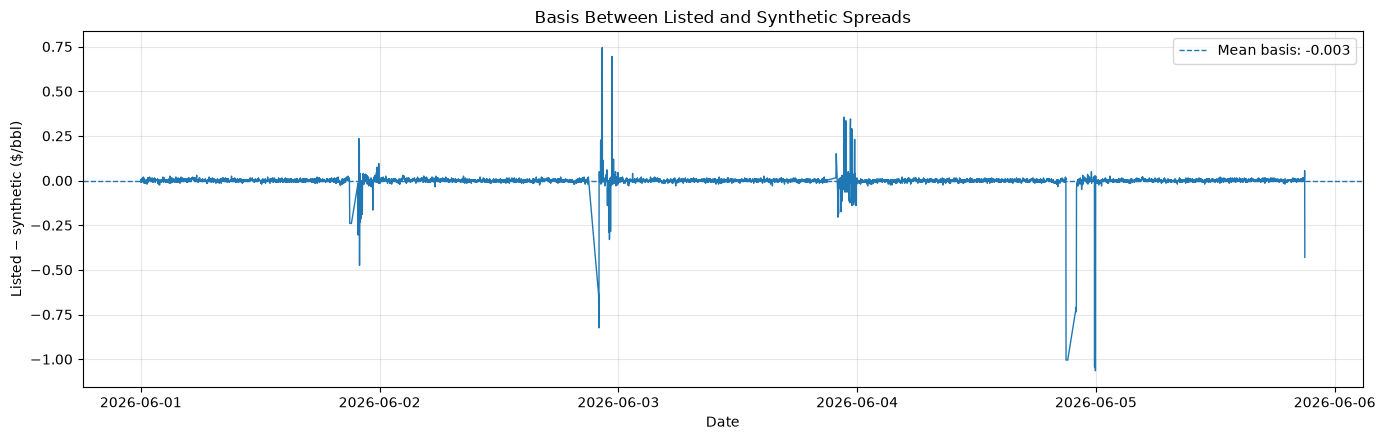

In [173]:
spread_comparison["basis"] = (
    spread_comparison["listed_mid"]
    - spread_comparison["synthetic_mid"]
)

fig, ax = plt.subplots(figsize=(14, 4.5))

ax.plot(
    spread_comparison.index,
    spread_comparison["basis"],
    linewidth=1,
)

ax.axhline(
    spread_comparison["basis"].mean(),
    linestyle="--",
    linewidth=1,
    label=f"Mean basis: {spread_comparison['basis'].mean():.3f}",
)

ax.set_title("Basis Between Listed and Synthetic Spreads")
ax.set_xlabel("Date")
ax.set_ylabel("Listed − synthetic ($/bbl)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The first requirement for using the listed spread as an execution instrument is
that it follows the same broad relative-price movements as the synthetic spread.

Besides a few dramatic deviations during late trading hours, which we have already discussed as being unreliable due to low trading activity and unintelligible exchange mechanics, the two lines remain very closely aligned throughout the week. This suggests that
the listed contract captures substantially the same economic exposure. 

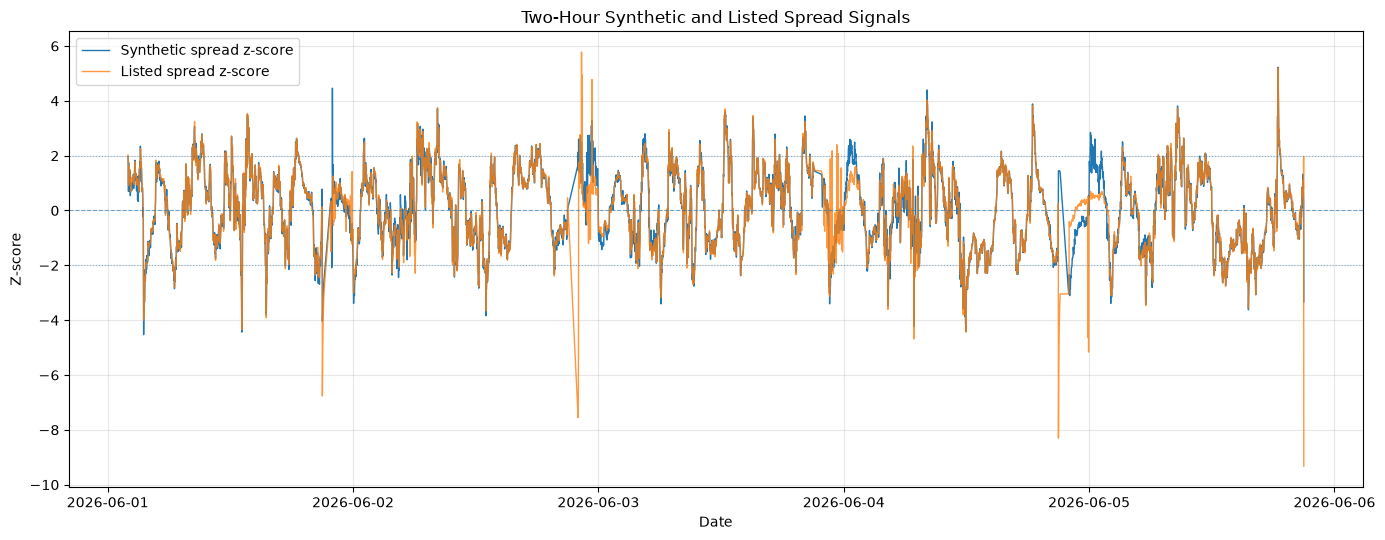

In [174]:
for column in ["synthetic_mid", "listed_mid"]:
    rolling_mean = (
        spread_comparison[column]
        .rolling(window=120, min_periods=120)
        .mean()
    )

    rolling_std = (
        spread_comparison[column]
        .rolling(window=120, min_periods=120)
        .std()
    )

    spread_comparison[f"{column}_zscore"] = (
        spread_comparison[column] - rolling_mean
    ) / rolling_std

signal_data = spread_comparison[
    [
        "synthetic_mid_zscore",
        "listed_mid_zscore",
    ]
].dropna()

signal_correlation = (
    signal_data["synthetic_mid_zscore"]
    .corr(signal_data["listed_mid_zscore"])
)

directional_agreement = (
    np.sign(signal_data["synthetic_mid_zscore"])
    == np.sign(signal_data["listed_mid_zscore"])
).mean()

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(
    signal_data.index,
    signal_data["synthetic_mid_zscore"],
    label="Synthetic spread z-score",
    linewidth=1,
)

ax.plot(
    signal_data.index,
    signal_data["listed_mid_zscore"],
    label="Listed spread z-score",
    linewidth=1,
    alpha=0.8,
)

ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(2, linestyle=":", linewidth=0.8, alpha=0.5)
ax.axhline(-2, linestyle=":", linewidth=0.8, alpha=0.5)

ax.set_title("Two-Hour Synthetic and Listed Spread Signals")
ax.set_xlabel("Date")
ax.set_ylabel("Z-score")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

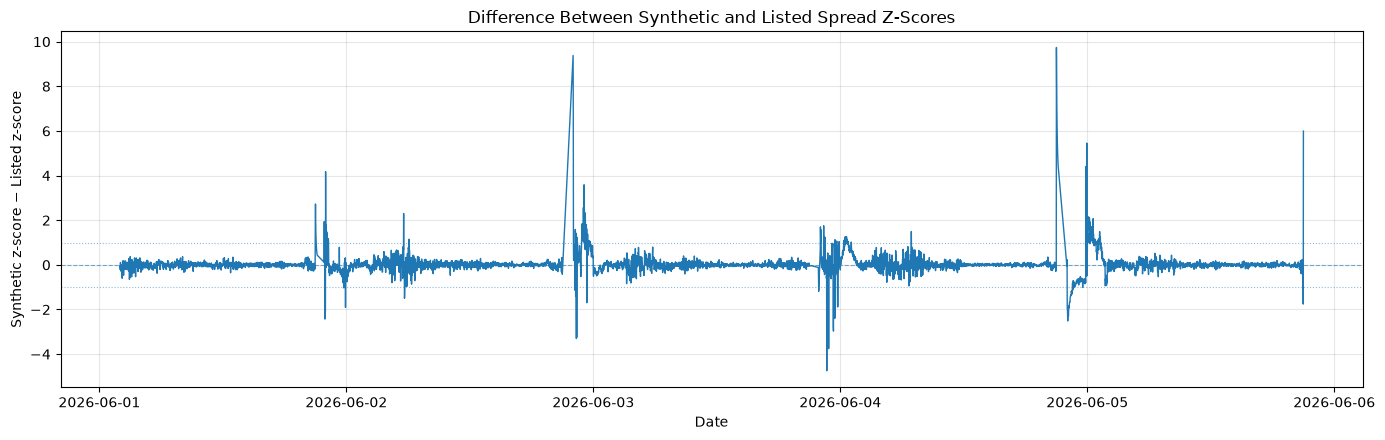

In [175]:
# Difference between the two z-score signals
signal_data = signal_data.copy()

signal_data["zscore_difference"] = (
    signal_data["synthetic_mid_zscore"]
    - signal_data["listed_mid_zscore"]
)

fig, ax = plt.subplots(figsize=(14, 4.5))

ax.plot(
    signal_data.index,
    signal_data["zscore_difference"],
    linewidth=1,
)

ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(1, linestyle=":", linewidth=0.8, alpha=0.5)
ax.axhline(-1, linestyle=":", linewidth=0.8, alpha=0.5)

ax.set_title("Difference Between Synthetic and Listed Spread Z-Scores")
ax.set_xlabel("Date")
ax.set_ylabel("Synthetic z-score − Listed z-score")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

This further comparison is the most direct test of whether the listed spread could
implement signals generated from the synthetic spread. The two z-scores generally move together (again, ignoring behavior in late hours), indicating that periods in which the synthetic
spread appears unusually wide or narrow are also reflected in the listed market.
This high directional agreement means that the two instruments usually imply the
same trade direction.

## 10. Rolling Dates in the Synthetic Spread

Because of the structure of CL.v.0 and BZ.v.0, our strategy must account for the fact that rolls will occur when the contracts that they represent change on a given day. This can cause deviations in the synthetic spread that aren't in response to ordinary swings but rather to the structural shift in the underlying data, but rather to a change in maturity composition of the two contracts (i.e. when a roll occurs one of the two futures will have switched to a contract with a later maturity date, whose price will consequently differ from the old one). Thus, the strategy may still trigger a trade signal if the size of the deviation is big enough. Let us explore how such rolls may impact the synethic spread by looking at data from a different time interval, since no rolls occur during our pilot dates (which we are able to see by noticing that the `is_roll_date` column remains `False` for all of the rows). 

In [176]:
ALIGNED_ROLL_FILE = (
    DATA_DIR
    / "clean"
    / "brent_wti_aligned_1m_2026-06-15_2026-06-24.parquet"
)

roll_full = pd.read_parquet(ALIGNED_ROLL_FILE).sort_index()
roll = roll_full.loc[
    "2026-06-16 00:00:00":"2026-06-19 23:00:00"
]

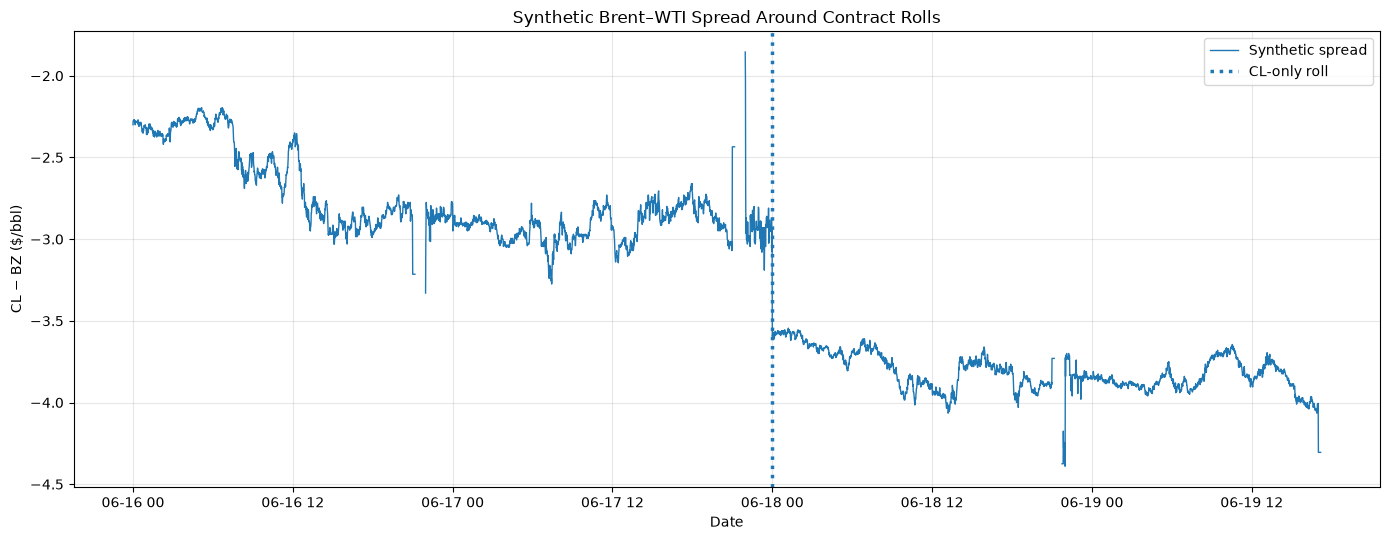

In [177]:
# One row per roll date, using the first minute of that date.
roll_dates = (
    roll.loc[roll["is_roll_date"]]
    .groupby(roll.loc[roll["is_roll_date"]].index.normalize())
    .first()
)

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(
    roll.index,
    roll["synth_mid"],
    linewidth=1,
    label="Synthetic spread",
)

for timestamp, row in roll_dates.iterrows():

    if row["cl_is_roll_date"]:
        label = "CL-only roll"
        linestyle = ":"
        linewidth = 2.5

    else:
        continue

    ax.axvline(
        timestamp,
        linestyle=linestyle,
        linewidth=linewidth,
        label=label,
    )

ax.set_title("Synthetic Brent–WTI Spread Around Contract Rolls")
ax.set_xlabel("Date")
ax.set_ylabel("CL − BZ ($/bbl)")
ax.grid(alpha=0.3)

# Remove repeated legend labels.
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
)

plt.tight_layout()
plt.show()

We see here a very clear impact on the synthetic spread as a result of a singular roll. In this set of dates, a roll occurs in CL.v.0 on June 18th, after which the synthetic spread price abruptly drops, before continuing its routine deviations throughout the 18th. This, as expected, coincides with CLN6 expiry's date, June 18th. Thus, it would be impossible to hold a listed spread that includes CLN6 through this date, as it would expire before this large signal is generated on the synthetic spread. However, this may not always be the case, as a roll need not necessarily always coincide with an expiration. 

The primary implication of this observation for our strategy is that our emerging theme of keeping its scope within a couple hours of a single day is reinforced, as longer holding periods may capture a roll and generate a false signal. At first glance, it appears we may need not necessarily cease trading based on the signal for the entire day on which the roll occurs, because as we can see, the synthetic spread continues its routine deviations once the roll is complete. However, in practice, this would be difficult to fully and safely implement in our strategy, as the `is_roll_date` flag returns `True` for all minutes of the day on which a roll occurs, and given different contract specs and unpredictability surrounding the exact minute on which a roll may occur, the safest approach would be to render all signals generated on a roll date as stale, so that we are protected against potentially false signals. 

# Conclusions

This exploratory analysis provides preliminary support for an intraday
relative-value strategy between WTI and Brent, while also showing that the
relationship is more conditional than a simple always-mean-reverting framework
would suggest.

WTI and Brent exhibit strong positive short-horizon correlation, which is
consistent with their shared exposure to the global crude-oil market. Their
movements are not identical, however, and these temporary differences generate
meaningful variation in the synthetic spread

$$
S_t = CL_t - BZ_t.
$$

The raw spread does not appear to revert toward one fixed level over the full
sample. Its local center changes through time, meaning that a strategy based on
one long-run historical mean would be vulnerable to regime shifts and changes in
the futures curves. The strategy should instead estimate a dynamic local
equilibrium using a rolling window.

Among the horizons examined, the 2-hour trailing mean provides a useful initial
reference. It is less sensitive to short-term noise than the 30-minute mean,
while adapting more quickly than the 1-day mean. Deviations from the 2-hour mean
are concentrated near zero, and large positive and negative deviations are
generally followed by spread movements in the opposite direction. This provides
encouraging evidence of short-horizon mean-reverting behavior.

However, the stationarity tests provide an important qualification. The spread
is not consistently stationary, even within short intraday windows. The ADF test
supports stationarity in only about 12%–13% of the tested windows, while both ADF
and KPSS support stationarity in approximately 8.1% of 1-hour windows and 6.3%
of 2-hour windows. Shortening the window improves the KPSS result but does not
materially improve the ADF pass rate.

This suggests that mean reversion is a regime-dependent property rather than a
permanent feature of the spread. The earlier visual pullbacks are meaningful,
but an extreme deviation should not automatically be interpreted as a trading
opportunity. In many windows, the spread may be trending, shifting to a new local
level, or behaving too persistently for a reliable mean-reversion trade.

Stationarity should therefore be incorporated as a signal-quality or regime
filter. Before entering a trade, the strategy should evaluate whether the recent
spread history is sufficiently consistent with a stable local relationship.
A strict rule requiring both ADF and KPSS to pass would produce relatively few
trades, so the final backtest should compare this rule with less restrictive
alternatives, such as using one test alongside an estimated mean-reversion speed,
half-life, or other evidence of convergence. The filter should only be retained
if qualifying windows produce stronger forward reversals and better net trading
performance.

Market behavior also varies materially throughout the day. Liquidity and the
relationship between WTI and Brent weaken near the daily exchange break,
producing stale quotes, discontinuities, and lower correlation. The strategy
should therefore operate only during sufficiently active trading hours, should
not treat the maintenance break as an ordinary continuation of the time series,
and should remain flat across the session boundary.

The synthetic spread is a useful signal because it directly measures the
relative movement of the two outright contracts. Execution, however, does not
necessarily need to occur through separate CL and BZ orders. An exchange-listed
Brent–WTI spread may provide a cleaner implementation through a single order
book, potentially reducing transaction costs and eliminating legging risk.

Using a listed spread is valid only when it represents the same contract
maturities as the synthetic signal. Its short-term price movements, deviations,
and trade direction should closely track the synthetic spread, and its order
book must be active and sufficiently narrow. A stable difference in price level
between the synthetic and listed spreads is not necessarily problematic, but
unstable tracking or disagreement during extreme signals would make it an
unreliable execution instrument.

Contract rolls are another critical implementation consideration. Because
`CL.v.0` and `BZ.v.0` are volume-ranked continuous contracts, the underlying
instrument represented by each series changes through time. A roll can create a
large discontinuity in the synthetic spread because the strategy begins
comparing a different pair of expiries. This movement may reflect the calendar
structure of the futures curves rather than a temporary mispricing.

The strategy should therefore:

- exclude roll dates and session boundaries from ordinary signal generation;
- close or avoid opening positions around contract transitions;
- reset rolling means, volatilities, stationarity tests, correlations, and
  z-scores after a roll;
- identify the active CL and BZ instrument IDs before selecting an execution
  contract;
- require the listed spread to match the currently active synthetic legs;
- require an expected reversion large enough to exceed transaction costs,
  slippage, and commissions;
- and use stationarity as a conditional filter rather than assuming the spread
  is always mean-reverting.

Overall, the data support continuing with the strategy, but not with an
unconditional rule that fades every large deviation. The strongest version of
the framework is a selective intraday strategy that trades only when the spread
is unusually far from a recent local mean, the underlying relationship appears
stationary enough to support reversion, liquidity is healthy, no session or
contract boundary is nearby, and the expected move exceeds realistic execution
costs.

The next stage is to convert these findings into explicit entry, exit,
position-sizing, stationarity-filter, execution, and risk-management rules and
evaluate them through a realistic out-of-sample backtest.
